# 11 — Modelo LightGBM (Fase 2)

Cuarto modelo de la familia "ensamble de árboles" evaluado en el proyecto, junto a XGBoost (`06`).
Sigue exactamente el mismo pipeline de datos y features que los demás modelos (`05_features_compartidas_juan.ipynb`),
para que la comparación en `07`/`10` sea limpia: mismo train (2019-2025), mismo test (2026), mismas 33 features,
mismo horizonte de 24h y misma transformación logarítmica del target.

**Por qué LightGBM además de XGBoost:** motivación de la tabla de selección de modelos — adecuación alta al
pronóstico de series de tiempo tabulares (categoría "Ensamble"), complejidad computacional media y, a diferencia
de XGBoost, crecimiento *leaf-wise* de los árboles (en vez de *level-wise*), lo que en datasets con muchas
variables correlacionadas (rezagos de precio, hidrología rezagada y sus derivadas) puede converger a un ajuste
mejor con el mismo número de árboles. Limitación conocida: al igual que XGBoost, no entiende la estructura de
serie de tiempo por sí solo (no hay componente autorregresivo nativo) — depende por completo de que los
rezagos/medias móviles ya estén en las features.

In [4]:
# --- Celda de arranque ---
import pandas as pd
import numpy as np
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontré '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raíz del proyecto:", RAIZ)

def calcular_metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error) / y_real).mean() * 100
    print(f"{nombre:25s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")
    return mae, rmse, mape

Raíz del proyecto: c:\Users\rafad\Downloads\Proyecto_Final\xm-spot-price-predictor


In [5]:
# --- Celda 1: Cargar features y armar X / y (idéntico a 06_modelo_xgboost_juan.ipynb) ---
df_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2019_2025.csv", parse_dates=["fecha_hora"])
df_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2026.csv", parse_dates=["fecha_hora"])

# Excluidas a propósito, no por descuido (mismo criterio que 06):
# - demanda, generacion: se determinan al mismo tiempo que el precio (no se
#   conocerían de antemano en un pronóstico real de 24-72h)
# - fecha_hora, anio, mes, hora, dia_semana, dia_anio (crudos): ya están
#   representados por sus versiones seno/coseno, que capturan mejor la
#   ciclicidad; dejar ambas versiones solo reparte la importancia entre
#   columnas redundantes en el análisis de feature importance
columnas_excluir = ["fecha_hora", "precio_bolsa", "demanda", "generacion",
                     "anio", "mes", "hora", "dia_semana", "dia_anio"]
columnas_features = [c for c in df_train.columns if c not in columnas_excluir]

X_train = df_train[columnas_features]
y_train = np.log(df_train["precio_bolsa"])  # mismo log-transform que XGBoost/Prophet, por consistencia metodológica

X_test = df_test[columnas_features]
y_test = df_test["precio_bolsa"]  # se compara en escala real, no en log

print("Features usadas:", columnas_features)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Features usadas: ['volumen_embalses', 'aportes_hidricos', 'oni', 'es_pandemia', 'precio_lag24h', 'precio_lag168h', 'precio_media_24h', 'precio_media_7d', 'precio_media_30d', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'dia_anio_sin', 'dia_anio_cos', 'volumen_embalses_delta_1d', 'volumen_embalses_delta_7d', 'volumen_embalses_media_7d', 'volumen_embalses_media_30d', 'volumen_embalses_vs_media30d', 'aportes_hidricos_delta_1d', 'aportes_hidricos_delta_7d', 'aportes_hidricos_media_7d', 'aportes_hidricos_media_30d', 'aportes_hidricos_vs_media30d', 'precio_std_24h', 'precio_std_7d', 'precio_rango_24h', 'ratio_volatilidad', 'demanda_lag24h', 'demanda_lag48h', 'demanda_lag72h', 'demanda_media_24h']

Train: (60625, 33) | Test: (5208, 33)


In [6]:
# --- Celda 2: Entrenar LightGBM, configuración base (sin tunear todavía) ---
import lightgbm as lgb

modelo_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    num_leaves=63,          # 2**6 - 1, para que max_depth sí sea la restricción efectiva
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

modelo_lgb.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


In [7]:
# --- Celda 3: Predecir sobre 2026 y evaluar contra persistencia ---
pred_log = modelo_lgb.predict(X_test)
y_pred = np.exp(pred_log)

print("Predicciones negativas:", (y_pred < 0).sum())

serie_precio = pd.concat([
    df_train[["fecha_hora", "precio_bolsa"]],
    df_test[["fecha_hora", "precio_bolsa"]]
]).sort_values("fecha_hora").reset_index(drop=True)
serie_precio["persistencia"] = serie_precio["precio_bolsa"].shift(24)
persistencia_test = serie_precio[serie_precio["fecha_hora"].isin(df_test["fecha_hora"])]["persistencia"].values

calcular_metricas(y_test, y_pred, "LightGBM (base, sin tunear)")
calcular_metricas(y_test, persistencia_test, "Persistencia")
print("\nReferencia -- XGBoost final (06): MAE 61.15 | RMSE 107.32 | MAPE 15.89%")
print("Referencia -- ARX+GARCH(1,1) (08): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")
print("Referencia -- N-BEATSx (09): MAE 56.11 | RMSE 100.92 | MAPE 15.93%")

Predicciones negativas: 0
LightGBM (base, sin tunear) MAE:    65.60  RMSE:   106.51  MAPE:  18.00%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- XGBoost final (06): MAE 61.15 | RMSE 107.32 | MAPE 15.89%
Referencia -- ARX+GARCH(1,1) (08): MAE 55.76 | RMSE 109.97 | MAPE 15.43%
Referencia -- N-BEATSx (09): MAE 56.11 | RMSE 100.92 | MAPE 15.93%


In [8]:
# --- Diagnóstico: error por régimen de ONI, igual que se hizo con los demás modelos ---
resultado_lgb = df_test[["fecha_hora", "oni"]].copy()
resultado_lgb["y"] = y_test.values
resultado_lgb["yhat"] = y_pred
resultado_lgb["error_abs"] = (resultado_lgb["y"] - resultado_lgb["yhat"]).abs()

mediana_oni = resultado_lgb["oni"].median()
alto = resultado_lgb[resultado_lgb["oni"] >= mediana_oni]
bajo = resultado_lgb[resultado_lgb["oni"] < mediana_oni]

print(f"LightGBM -- Error medio con ONI alto (>= {mediana_oni:.2f}): {alto['error_abs'].mean():.2f}")
print(f"LightGBM -- Error medio con ONI bajo (< {mediana_oni:.2f}):  {bajo['error_abs'].mean():.2f}")
print(f"Razón alto/bajo: {alto['error_abs'].mean() / bajo['error_abs'].mean():.2f}x")
print("\nReferencia -- XGBoost: 86.83 / 23.73 (razón 3.66x)")
print("Referencia -- ARX+GARCH: 78.84 / 22.98 (razón 3.43x)")

LightGBM -- Error medio con ONI alto (>= 0.35): 96.82
LightGBM -- Error medio con ONI bajo (< 0.35):  34.39
Razón alto/bajo: 2.82x

Referencia -- XGBoost: 86.83 / 23.73 (razón 3.66x)
Referencia -- ARX+GARCH: 78.84 / 22.98 (razón 3.43x)


In [9]:
# --- Grid search de LightGBM, validando con 2025 (no tocar 2026 todavía) ---
# Mismo protocolo que 06: última porción de train (2025) como validación, misma rejilla
# de max_depth/learning_rate para que la comparación entre modelos sea directa.
import itertools

train_gs = df_train[df_train["fecha_hora"] < "2025-01-01"]
valid_gs = df_train[df_train["fecha_hora"] >= "2025-01-01"]

X_train_gs = train_gs[columnas_features]
y_train_gs = np.log(train_gs["precio_bolsa"])
X_valid_gs = valid_gs[columnas_features]
y_valid_gs = valid_gs["precio_bolsa"]

print(f"Train GS: {len(train_gs)} | Valid GS: {len(valid_gs)}")

rejilla = {
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
}
combinaciones = [dict(zip(rejilla.keys(), valores)) for valores in itertools.product(*rejilla.values())]

resultados_gs = []
for i, params in enumerate(combinaciones, 1):
    num_leaves = min(63, max(2, 2 ** params["max_depth"] - 1))
    m = lgb.LGBMRegressor(n_estimators=500, num_leaves=num_leaves, subsample=0.8,
                           colsample_bytree=0.8, random_state=42, verbose=-1, **params)
    m.fit(X_train_gs, y_train_gs)
    pred = np.exp(m.predict(X_valid_gs))

    mae = np.abs(y_valid_gs.values - pred).mean()
    resultados_gs.append({**params, "mae": mae})
    print(f"[{i}/{len(combinaciones)}] {params} -> MAE {mae:.2f}")

df_gs_lgb = pd.DataFrame(resultados_gs).sort_values("mae").reset_index(drop=True)
df_gs_lgb

Train GS: 51865 | Valid GS: 8760
[1/9] {'max_depth': 3, 'learning_rate': 0.01} -> MAE 45.22
[2/9] {'max_depth': 3, 'learning_rate': 0.05} -> MAE 45.94
[3/9] {'max_depth': 3, 'learning_rate': 0.1} -> MAE 47.74
[4/9] {'max_depth': 6, 'learning_rate': 0.01} -> MAE 45.62
[5/9] {'max_depth': 6, 'learning_rate': 0.05} -> MAE 49.45
[6/9] {'max_depth': 6, 'learning_rate': 0.1} -> MAE 52.00
[7/9] {'max_depth': 9, 'learning_rate': 0.01} -> MAE 46.17
[8/9] {'max_depth': 9, 'learning_rate': 0.05} -> MAE 50.07
[9/9] {'max_depth': 9, 'learning_rate': 0.1} -> MAE 52.11


,max_depth,learning_rate,mae
0,3,0.01,45.223074
1,6,0.01,45.617405
2,3,0.05,45.943541
3,9,0.01,46.171493
4,3,0.10,47.737871
5,6,0.05,49.446361
6,9,0.05,50.074841
7,6,0.10,51.996205
8,9,0.10,52.112624


In [10]:
# --- Refinamiento: con el learning_rate que de verdad ganó, afinar max_depth ---
mejor_lr = df_gs_lgb.iloc[0]["learning_rate"]
rejilla_fina = [1, 2, 3, 4, 5]

resultados_gs2 = []
for i, depth in enumerate(rejilla_fina, 1):
    num_leaves = min(63, max(2, 2 ** depth - 1))
    m = lgb.LGBMRegressor(n_estimators=500, learning_rate=mejor_lr, max_depth=depth,
                           num_leaves=num_leaves, subsample=0.8, colsample_bytree=0.8,
                           random_state=42, verbose=-1)
    m.fit(X_train_gs, y_train_gs)
    pred = np.exp(m.predict(X_valid_gs))

    mae = np.abs(y_valid_gs.values - pred).mean()
    resultados_gs2.append({"max_depth": depth, "mae": mae})
    print(f"[{i}/{len(rejilla_fina)}] max_depth={depth} -> MAE {mae:.2f}")

df_gs_lgb2 = pd.DataFrame(resultados_gs2).sort_values("mae").reset_index(drop=True)
df_gs_lgb2

[1/5] max_depth=1 -> MAE 50.32
[2/5] max_depth=2 -> MAE 47.21
[3/5] max_depth=3 -> MAE 45.22
[4/5] max_depth=4 -> MAE 44.08
[5/5] max_depth=5 -> MAE 44.78


,max_depth,mae
0,4,44.077560
1,5,44.782372
2,3,45.223074
3,2,47.214673
4,1,50.320496


In [11]:
# --- Modelo LightGBM final: mejores max_depth/learning_rate del grid search, sobre 2019-2025 completo ---
mejor_depth_final = int(df_gs_lgb2.iloc[0]["max_depth"])
mejor_num_leaves_final = min(63, max(2, 2 ** mejor_depth_final - 1))

modelo_lgb_final = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=mejor_depth_final,
    num_leaves=mejor_num_leaves_final,
    learning_rate=mejor_lr,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

modelo_lgb_final.fit(X_train, y_train)  # X_train/y_train ya son 2019-2025 completo, de la Celda 1

pred_log_final = modelo_lgb_final.predict(X_test)
y_pred_final = np.exp(pred_log_final)

print(f"Configuración final: max_depth={mejor_depth_final}, num_leaves={mejor_num_leaves_final}, learning_rate={mejor_lr}")
print("Predicciones negativas:", (y_pred_final < 0).sum())

calcular_metricas(y_test, y_pred_final, "LightGBM final")
calcular_metricas(y_test, persistencia_test, "Persistencia")
print("\nReferencia -- XGBoost final (06): MAE 61.15 | RMSE 107.32 | MAPE 15.89%")
print("Referencia -- ARX+GARCH(1,1) (08): MAE 55.76 | RMSE 109.97 | MAPE 15.43%")
print("Referencia -- N-BEATSx (09): MAE 56.11 | RMSE 100.92 | MAPE 15.93%")

Configuración final: max_depth=4, num_leaves=15, learning_rate=0.01
Predicciones negativas: 0
LightGBM final            MAE:    62.16  RMSE:   108.06  MAPE:  15.90%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- XGBoost final (06): MAE 61.15 | RMSE 107.32 | MAPE 15.89%
Referencia -- ARX+GARCH(1,1) (08): MAE 55.76 | RMSE 109.97 | MAPE 15.43%
Referencia -- N-BEATSx (09): MAE 56.11 | RMSE 100.92 | MAPE 15.93%


In [12]:
# --- Mismo diagnóstico de régimen, sobre el modelo final ---
resultado_lgb_final = df_test[["fecha_hora", "oni"]].copy()
resultado_lgb_final["y"] = y_test.values
resultado_lgb_final["yhat"] = y_pred_final
resultado_lgb_final["error_abs"] = (resultado_lgb_final["y"] - resultado_lgb_final["yhat"]).abs()

alto = resultado_lgb_final[resultado_lgb_final["oni"] >= mediana_oni]
bajo = resultado_lgb_final[resultado_lgb_final["oni"] < mediana_oni]

print(f"LightGBM final -- ONI alto: {alto['error_abs'].mean():.2f}  |  ONI bajo: {bajo['error_abs'].mean():.2f}  |  razón {alto['error_abs'].mean()/bajo['error_abs'].mean():.2f}x")

LightGBM final -- ONI alto: 95.21  |  ONI bajo: 29.11  |  razón 3.27x


## Interpretabilidad: feature importance nativa de LightGBM

Importancia por ganancia total (`importance_type="gain"`), método complementario más rápido que SHAP para una
primera lectura de qué variables domina el modelo -- comparar contra el top de SHAP/permutation importance de
XGBoost (`06`) para ver si ambos algoritmos de árboles coinciden en qué features son las más relevantes.

precio_lag24h                   1.230799e+06
precio_media_24h                2.060236e+05
precio_media_7d                 4.071677e+04
precio_lag168h                  2.302564e+04
dia_semana_sin                  4.319263e+03
aportes_hidricos_delta_7d       4.129960e+03
aportes_hidricos_vs_media30d    3.466509e+03
hora_sin                        3.366965e+03
volumen_embalses_delta_7d       3.266490e+03
demanda_lag72h                  2.940976e+03
dia_anio_cos                    2.810710e+03
precio_media_30d                1.955970e+03
aportes_hidricos                1.919686e+03
precio_std_7d                   1.816058e+03
dia_semana_cos                  1.727597e+03
dtype: float64


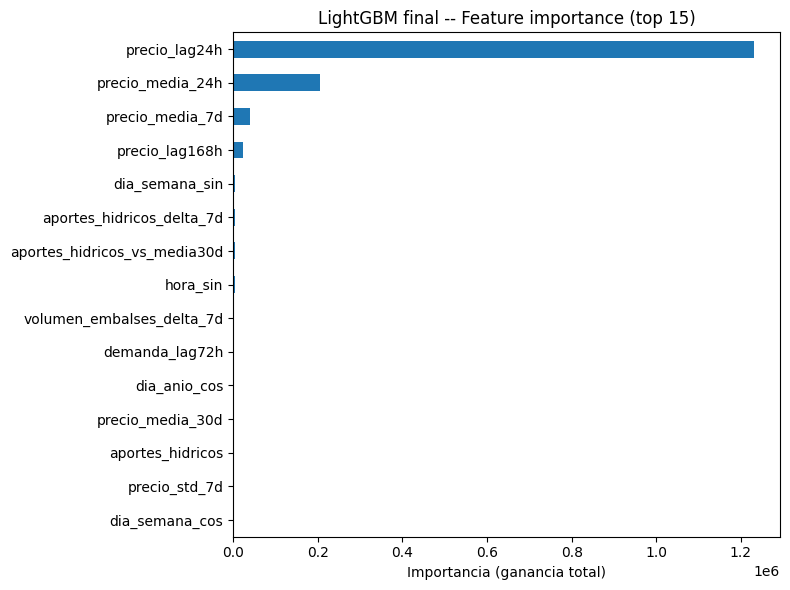

In [13]:
# --- Feature importance nativa (ganancia total), top 15 ---
import matplotlib.pyplot as plt

importancia = pd.Series(modelo_lgb_final.booster_.feature_importance(importance_type="gain"),
                         index=columnas_features).sort_values(ascending=False)

top15 = importancia.head(15)
print(top15)

plt.figure(figsize=(8, 6))
top15.iloc[::-1].plot(kind="barh")
plt.xlabel("Importancia (ganancia total)")
plt.title("LightGBM final -- Feature importance (top 15)")
plt.tight_layout()
plt.show()

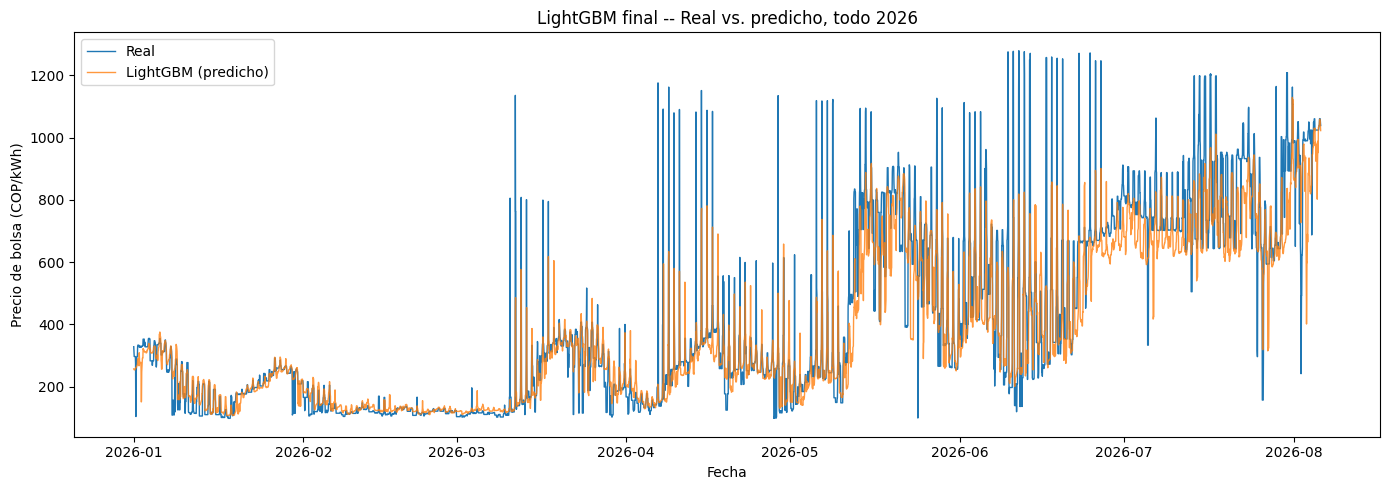

In [14]:
# --- Gráfica: todo 2026, real vs. predicho ---
plt.figure(figsize=(14, 5))
plt.plot(df_test["fecha_hora"], y_test, label="Real", linewidth=1)
plt.plot(df_test["fecha_hora"], y_pred_final, label="LightGBM (predicho)", linewidth=1, alpha=0.8)
plt.xlabel("Fecha")
plt.ylabel("Precio de bolsa (COP/kWh)")
plt.title("LightGBM final -- Real vs. predicho, todo 2026")
plt.legend()
plt.tight_layout()
plt.show()

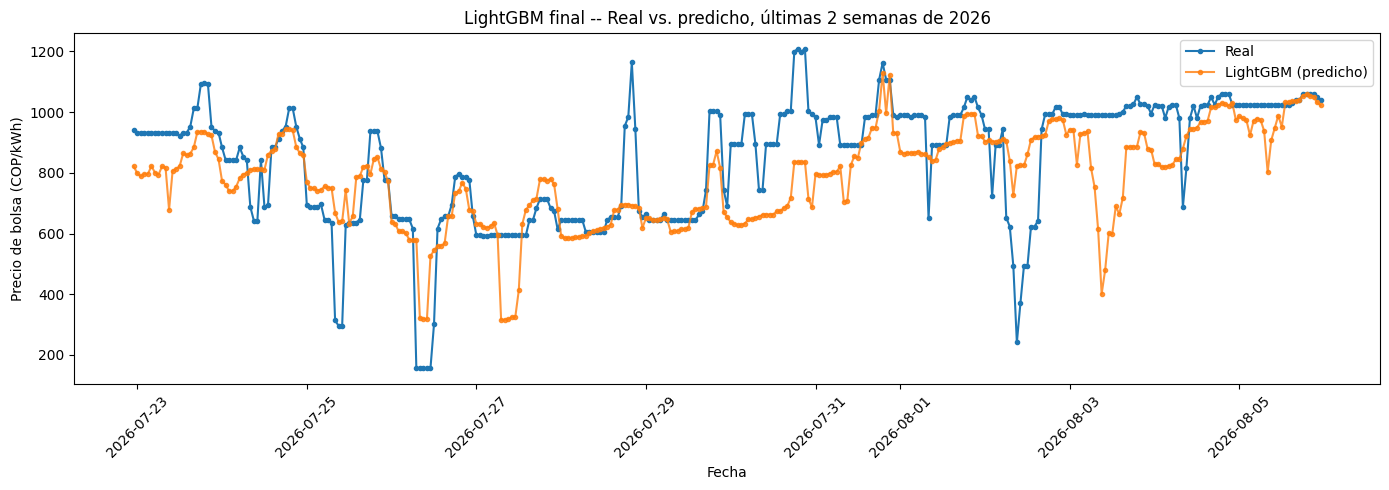

In [15]:
# --- Gráfica: zoom a las últimas 2 semanas, para ver el detalle hora a hora ---
ultimas_2_semanas = df_test["fecha_hora"] >= (df_test["fecha_hora"].max() - pd.Timedelta(days=14))

plt.figure(figsize=(14, 5))
plt.plot(df_test.loc[ultimas_2_semanas, "fecha_hora"], y_test[ultimas_2_semanas.values], label="Real", marker=".")
plt.plot(df_test.loc[ultimas_2_semanas, "fecha_hora"], y_pred_final[ultimas_2_semanas.values],
         label="LightGBM (predicho)", marker=".", alpha=0.8)
plt.xlabel("Fecha")
plt.ylabel("Precio de bolsa (COP/kWh)")
plt.title("LightGBM final -- Real vs. predicho, últimas 2 semanas de 2026")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Lectura de resultados:** ver salida de las celdas de arriba tras ejecutar. Pendiente de trasladar el
resultado final (MAE/RMSE/MAPE, razón ONI alto/bajo) a la tabla comparativa del `README.md` una vez confirmado
con el resto del equipo, y de incluir LightGBM en el walk-forward de 6 orígenes (`07`) y en la prueba de
Diebold-Mariano (`10`) si el resultado en el holdout de 2026 lo justifica frente a los modelos ya evaluados.